<a href="https://colab.research.google.com/github/PMSense/AI-Security-/blob/main/Slam_Laqtib_project1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Project 1: Digit Classification with KNN


# Intro
---
In this project, you'll implement your own image recognition system for classifying digits. Read through the code and the instructions carefully and add your own code where indicated. Each problem can be addressed succinctly with the included packages -- please don't add any more.
As always, you're welcome to work on the project in groups and discuss ideas over Slack, but <b> please prepare your own write-up (with your own code). </b> To be safe, please credit any sources used.


## Grading
---
 - Make sure to answer every part in every question.
 - There are 5 questions, each worth an equal number of points.
 - Read carefully what is asked including the notes.
 - Additional points may be deducted if:
   - the code is not clean or is not well commented
   - the functions or answers are excessively long

## Requirements:
---
1. Comment your code.
1. Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own.
1. All code must run on colab.research.google.com
1. You should not import any additional libraries.
1. Try and minimize the use of the global namespace (meaning, keep things inside functions).

## Additional reading and notes
---

If you are looking to get started with Tensorflow, you can read through this tutorial: https://www.tensorflow.org/tutorials/keras/classification. It uses a dataset called "fashion_mnist", which is identical in structure to the original digit mnist, but uses images of clothing rather than images of digits. The number of training examples and number of labels is the same. In fact, you can simply replace the code that loads "fashion_mnist" with "mnist" and everything should work fine.

Additionally, if you're interested, check out these links related to digit recognition:

* Yann Lecun's MNIST benchmarks: http://yann.lecun.com/exdb/mnist/
* Stanford Streetview research and data: http://ufldl.stanford.edu/housenumbers/

In [ ]:
# This tells matplotlib not to try opening a new window for each plot.
%matplotlib inline

# Import a bunch of libraries.
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from sklearn.pipeline import Pipeline
from sklearn.datasets import fetch_openml
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

# Set the randomizer seed so results are the same each time.
np.random.seed(0)

In [ ]:
import sklearn
sklearn.__version__

'1.6.1'

Load the data. Notice that the data gets partitioned into training, development, and test sets. Also, a small subset of the training data called mini_train_data and mini_train_labels gets defined, which you should use in all the experiments below, unless otherwise noted.

In [ ]:
# Load the digit data from https://www.openml.org/d/554 or from default local location '~/scikit_learn_data/...'
X, Y = fetch_openml(name='mnist_784', return_X_y=True, cache=False)

# Rescale grayscale values to [0,1].
X = X / 255.0

# Shuffle the input: create a random permutation of the integers between 0 and the number of data points and apply this
# permutation to X and Y.
# NOTE: Each time you run this cell, you'll re-shuffle the data, resulting in a different ordering.
shuffle = np.random.permutation(np.arange(X.shape[0]))
X, Y = X.iloc[shuffle], Y.iloc[shuffle]

print('data shape: ', X.shape)
print('label shape:', Y.shape)

# Set some variables to hold test, dev, and training data.
test_data, test_labels = X[61000:], Y[61000:]
dev_data, dev_labels = X[60000:61000], Y[60000:61000]
train_data, train_labels = X[:60000], Y[:60000]
mini_train_data, mini_train_labels = X[:1000], Y[:1000]

data shape:  (70000, 784)
label shape: (70000,)


### Question 1: Visualize a select sample of images
---
Show a 10x10 grid that visualizes 10 examples of each digit.

Notes:
* Make the digits nice and big.
* You can use `plt.rc()` for setting the colormap, for example to black and white.
* You can use `plt.subplot()` for creating subplots.
* You can use `plt.imshow()` for rendering a matrix.
* You can use `np.array.reshape()` for reshaping a 1D feature vector into a 2D matrix (for rendering).

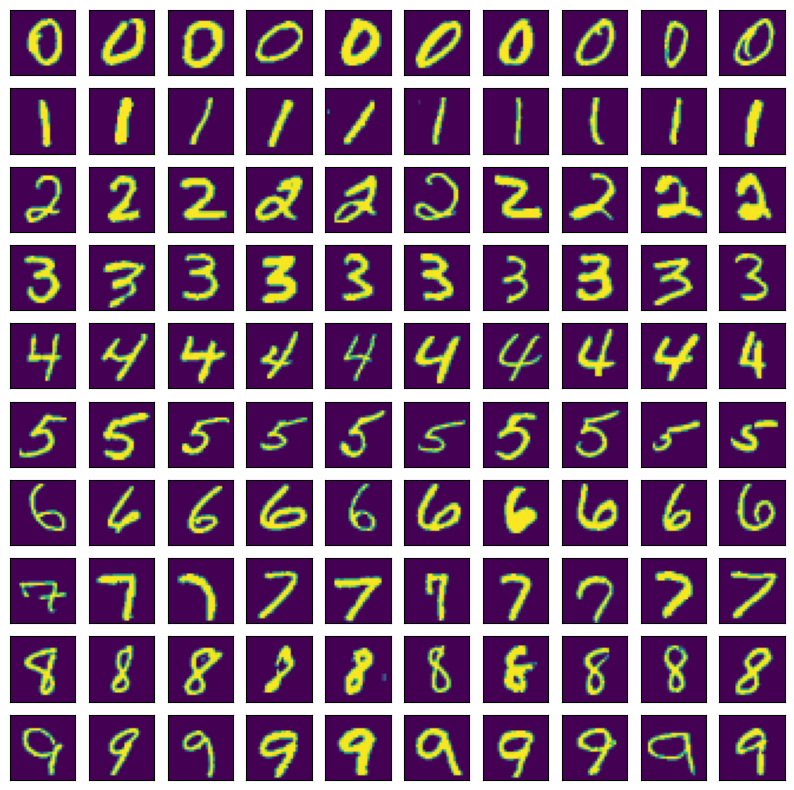

In [ ]:
def Q1(num_examples=10):

  ### STUDENT START ###

  # Generates a 10x10 grid that visualizes 10 examples of each digit (0-9).
  plt.figure(figsize=(10, 10))
  plt.rc('image', cmap='viridis') # set up the color map

  # loop through each digit from 0 to 9
  for digit in range(10):

    # find the first 10 examples of the current digit
    # search the train_labels for enteries that match the current digit
    # np.where() finds the row indices where the label matches our digit. We take the first 10.
    indices = np.where(train_labels == str(digit))[0][:10]  # labels are strings (e.g., '0', '1')


    # loop through the 10 examples to plot them
    for i, image_index in enumerate(indices):

      # calculate the position in the 10x10 grid
      # the subplot index is 1-based and goes from left to right, top to bottom.
      # for digit 0, this will be plots 1-10. For digit 1, plots 11-20, etc.
      subplot_position = digit * 10 + i + 1
      plt.subplot(10, 10, subplot_position)

      # prepare and display the image
      # remove the axis ticks and grid for a cleaner look.
      plt.xticks([])
      plt.yticks([])
      plt.grid(False)

      # reshape the 1D vector of 784 pixels into a 2D 28x28 matrix for rendering.
      image_data = train_data.iloc[image_index].values.reshape(28, 28)
      plt.imshow(image_data)

  # Display the final grid of images
  plt.show()

  ### STUDENT END ###

Q1(10)




```
# This is formatted as code
```

### Question 2: Evaluating different choices of k
---

1. Produce k-Nearest Neighbors models with k = 1, 3, 5, 7, and 9.  
1. Print the accuracy of each model.
1. Additionally, only for the 1-Nearest Neighbor model, show the precision, recall, and F1 for each label.
1. Which digit is the most *difficult* for the 1-Nearest Neighbor model to classify correctly? How did you choose and why?

Notes:
* Train on the mini train set.
* Evaluate performance on the dev set.
* Print only the information asked so it is easy to read and compare.
* You can use `KNeighborsClassifier` to produce a k-nearest neighbor model.
* You can use `classification_report` to get precision, recall, and F1 results.
* Check out what the function "score" does.

In [ ]:
def Q2(k_values):

### STUDENT START ###

  # Loop through the given k values
  for k in k_values:

    # Build and train a new KNeighborsClassifier model
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(mini_train_data, mini_train_labels)

    # Calculate and print the accuracy on the dev set
    accuracy = knn_model.score(dev_data, dev_labels)

    # Only for k=1, we will show the detailed/formatted report
    if k == 1:
        predictions = knn_model.predict(dev_data)
        report_dict = classification_report(dev_labels, predictions, output_dict=True)

        print("\n--- Detailed Report for k=1 ---")
        print(f"Digit:\t| Precision:\t Recall:\t F1-Score:")
        # Loop through the report and print stats for each digit
        for label, metrics in report_dict.items():
          if label.isdigit():
            p = metrics['precision']
            r = metrics['recall']
            f1 = metrics['f1-score']
            print(f"{label} \t| {p:.2f} \t\t {r:.2f} \t\t {f1:.2f}")

        print("-" * 50 + "\n")

    # Print the accuracy of each model
    print(f"k={k}, Accuracy: {accuracy:.3f}")

### STUDENT END ###

k_values = [1, 3, 5, 7, 9]
Q2(k_values)


--- Detailed Report for k=1 ---
Digit:	| Precision:	 Recall:	 F1-Score:
0 	| 0.95 		 0.95 		 0.95
1 	| 0.89 		 0.98 		 0.93
2 	| 0.90 		 0.79 		 0.84
3 	| 0.93 		 0.87 		 0.90
4 	| 0.91 		 0.85 		 0.88
5 	| 0.86 		 0.88 		 0.87
6 	| 0.92 		 0.92 		 0.92
7 	| 0.85 		 0.94 		 0.89
8 	| 0.83 		 0.77 		 0.80
9 	| 0.80 		 0.86 		 0.83
--------------------------------------------------

k=1, Accuracy: 0.884
k=3, Accuracy: 0.876
k=5, Accuracy: 0.882
k=7, Accuracy: 0.877
k=9, Accuracy: 0.875


Answer to part 4:   
The most difficult digit to classify is 8 (F1-Score: 0.80). Because it has the smallest F1 score (which takes borth precision and recall into consideration)


### Question 3: Examining the importance of training size
---
1. Produce 1-Nearest Neighbor models using training data of various sizes. For example, ```train_data[:train_size]```.
1. Evaluate and show the accuracy achieved by each model.  
1. Show the time needed to:
  1. Train each model.
  1. Measure the accuracy of each model.
1. What do you see? Is this what you expected to see and why?
1. Plot on the same graph (as a function of training size):
  1. the time needed for training
  1. the time needed for calculating accuracy

Notes:
* Evaluate on the dev set.
* You can use `KNeighborsClassifier` to produce a k-nearest neighbor model.
* You can use `time.time()` to measure elapsed time of operations.

Training Size   | Accuracy   | Training Time (s)    | Evaluation Time (s) 
---------------------------------------------------------------------------
100             | 0.702      | 0.0061               | 0.0164              
200             | 0.791      | 0.0056               | 0.0217              
400             | 0.811      | 0.0062               | 0.0312              
800             | 0.866      | 0.0074               | 0.0566              
1600            | 0.905      | 0.0101               | 0.0941              
3200            | 0.927      | 0.0160               | 0.1862              
6400            | 0.939      | 0.0286               | 0.4058              
12800           | 0.952      | 0.0494               | 0.6734              
25600           | 0.963      | 0.1186               | 1.3757              



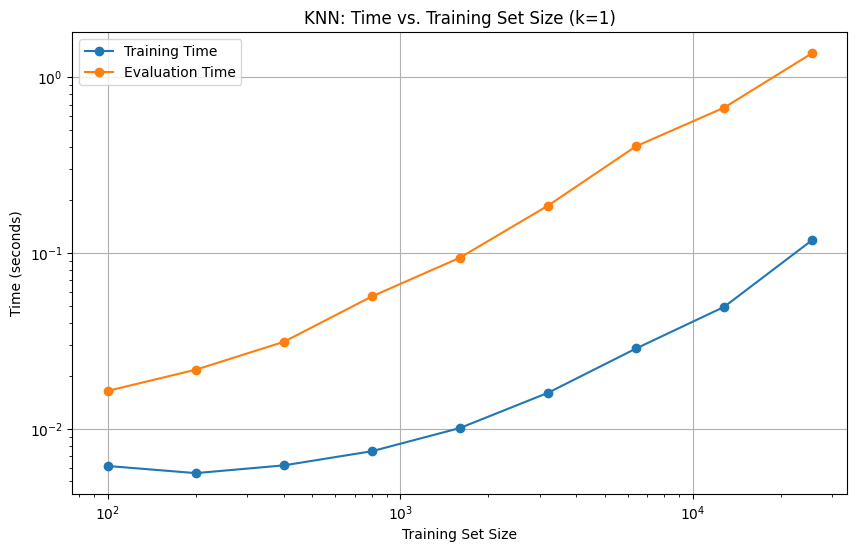



Question:  What do you see? Is this what you expected to see and why?


Answer - Analysis:

As training size increases, accuracy improves, evaluation time grows significantly, and training time remains near zero.
This is expected for KNN:
		 — Fitting the model is a 'lazy' memory operation fit() but fast because it doesn't do any processing, but
		 — Predicting requires comparing each new point to the entire training set (slow).


In [ ]:
def Q3(train_sizes, accuracies, train_times, eval_times):
  ### STUDENT START ###

  # Print a header for the results table
  print(f"{'Training Size':<15} | {'Accuracy':<10} | {'Training Time (s)':<20} | {'Evaluation Time (s)':<20}")
  print("-" * 75)

  # Loop through each specified training size
  for size in train_sizes:
    # Slice the training data to the current size
    X_subset = train_data[:size]
    Y_subset = train_labels[:size]

    # Produce 1-nearest neighbor model.
    knn_model = KNeighborsClassifier(n_neighbors=1)

    # Find the time the training (model.fit()) process
    start_time = time.time()
    knn_model.fit(X_subset, Y_subset)
    end_time = time.time()
    train_duration = end_time - start_time
    train_times.append(train_duration)

    # Find the time the evaluation (model.score()) process
    start_time = time.time()
    accuracy = knn_model.score(dev_data, dev_labels)
    end_time = time.time()
    eval_duration = end_time - start_time
    eval_times.append(eval_duration)

    # Save the accuracy
    accuracies.append(accuracy)

    # Print the results for the current size (accuracy, traiining time and evaluation time)
    print(f"{size:<15} | {accuracy:<10.3f} | {train_duration:<20.4f} | {eval_duration:<20.4f}")


  # After the loop, now generate the plot
  print()
  plt.figure(figsize=(10, 6))
  plt.plot(train_sizes, train_times, 'o-', label='Training Time')
  plt.plot(train_sizes, eval_times, 'o-', label='Evaluation Time')
  plt.xlabel('Training Set Size')
  plt.ylabel('Time (seconds)')
  plt.title('KNN: Time vs. Training Set Size (k=1)')
  plt.legend()
  plt.grid(True)
  plt.xscale('log')
  plt.yscale('log')
  plt.show()

  print("\n\nQuestion:  What do you see? Is this what you expected to see and why?")
  print("\n\nAnswer - Analysis:\n")

  print("As training size increases, accuracy improves, evaluation time grows significantly, and training time remains near zero.")
  print("This is expected for KNN:")
  print("\t\t — Fitting the model is a 'lazy' memory operation fit() but fast because it doesn't do any processing, but")
  print("\t\t — Predicting requires comparing each new point to the entire training set (slow).")

  ### STUDENT END ###

# The provided inputs for the function
train_sizes = [100, 200, 400, 800, 1600, 3200, 6400, 12800, 25600]
accuracies = []
train_times = []
eval_times = []

# Call the function to run the analysis
Q3(train_sizes, accuracies, train_times, eval_times)

### Question 4: Evaluating if we should obtain additional data
---

In this question we wish to predict what accuracy we would get if we had additional training data.

Our input, our features and labels, are the output from the previous question. Based on the training size and accuracy we got in the previous question, we wish to predict the accuracy we would get if we had larger training sizes.

1. Produce a linear regression model that predicts accuracy of a 1-Nearest Neighbor model given training set size.
1. Print $R^2$ of the linear regression model.  
1. Print the accuracies predicted for training set sizes 60000, 120000, and 1000000.  
1. Plot on a lineplot graph:
  1. the actual accuracies we obtained in the previous question
  1. and the accuracies our model predicted we would have gotten.
  1. The X axis is the training set size.
  1. You can limit the range of X and Y to the range where you have data for both plots. Meaning, in the this question, we want to visualize how good the prediction is.
1. What are two things that are wrong with our model?
1. Apply a transformation to the predictor features and a transformation to the outcome that make the predictions fix these issues.
1. Show $R^2$ of the improved linear regression model.  
1. Print the accuracies predicted for training set sizes 60000, 120000, and 1000000.  
1. Plot a lineplot graph of both again as before.
  1. Be sure to plot this where the Y axis is accuracy and X axis is training set size, **not the transformed space**!
  1. Choose the range of X and Y to visualize effectively.

Notes:
* Train the linear regression models on all of the (transformed) accuracies estimated in Problem 3.
* Evaluate the linear regression models on all of the (transformed) accuracies estimated in Problem 3.
* You can use `LinearRegression` to produce a linear regression model.
* Remember that the sklearn `fit()` functions take an input matrix X and output vector Y. So, each input example in X is a vector, even if it contains only a single value.
* Hints:
  1. You have two problems here, how well your model fits and predicting *illogical* values of accuracy.
  1. You can look at:
    1. [logit](https://en.wikipedia.org/wiki/Logit): $\frac{1}{1 + e^{-x}} = \frac{e^x}{1+e^x}$ which takes numbers in $\[\infty,-\infty\]$ and outputs numbers in $(0, 1)$.
    1. [logistic](https://en.wikipedia.org/wiki/Logistic_function): $log(\frac{p}{1 - p})$ which takes numbers between $(0, 1)$ and outputs numbers between $\[\infty,-\infty\]$.
    1. It also happens that $x = logistic(p)$ is the same thing as $logit(x)=p$.

--- 1st try:  Linear Regression w/ Original Data ---
R^2 of the simple model: 0.4177
Predicted accuracies for [60k, 120k, 1M]: [1.23617317 1.63742805 7.52249967]


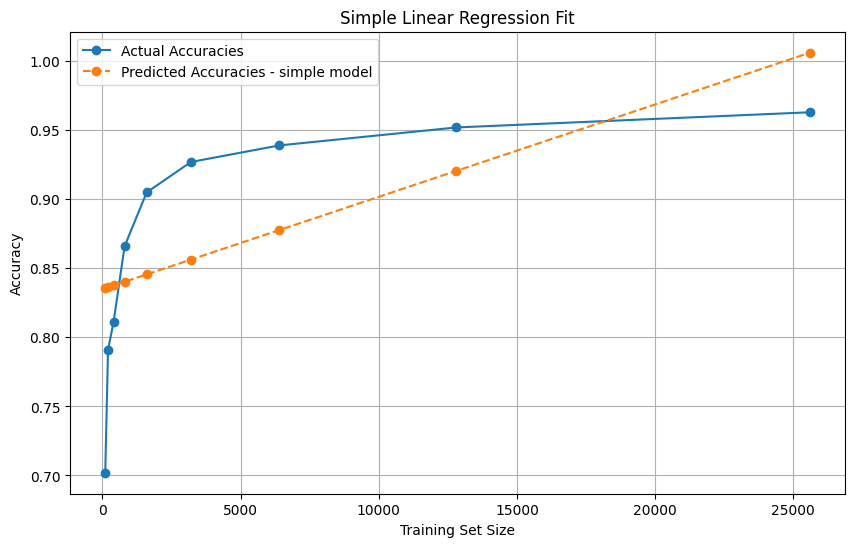


--- 2nd try: Improved Model with Transformations of data ---
R^2 of the improved model: 0.9897
Predicted accuracies for [60k, 120k, 1M] (Improved): [0.97575264 0.98186682 0.99260572]


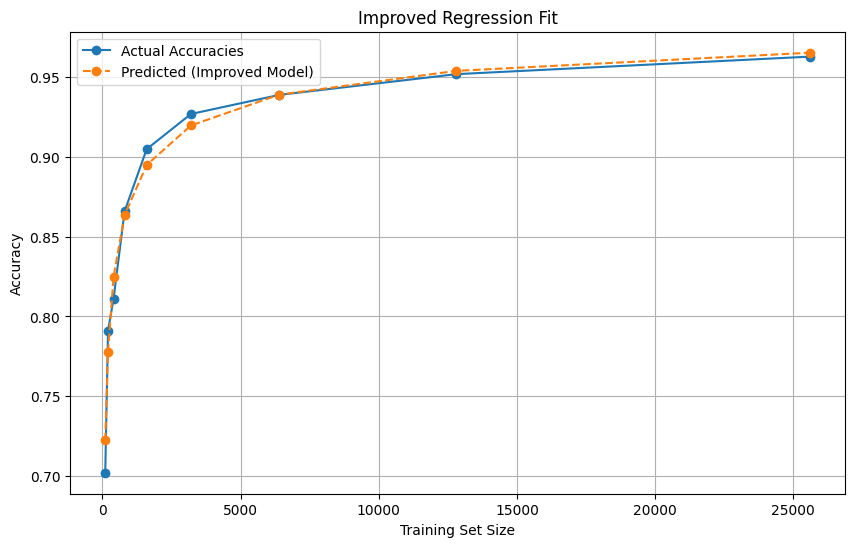

In [ ]:
def Q4():
  ### STUDENT START ###

  # Our train_sizes and accuracies are available from the previous question's run
  train_sizes = [100, 200, 400, 800, 1600, 3200, 6400, 12800, 25600]
  accuracies = [0.702, 0.791, 0.811, 0.866, 0.905, 0.927, 0.939, 0.952, 0.963]


  # Let's run our Linear Regression
  print("--- 1st try:  Linear Regression w/ Original Data ---")

  # transform the train data
  X_train = np.array(train_sizes)[:, np.newaxis]

  # create and transform test data
  test_sizes = [60000, 120000, 1000000]
  X_test = np.array(test_sizes)[:, np.newaxis]

  # linear regression fit and predict
  lr = LinearRegression(fit_intercept=True)
  lr.fit(X_train, accuracies)
  predictions = lr.predict(X_train)
  test_predictions = lr.predict(X_test)

  # print R^2 and predictions for the simple model
  r2_simple = lr.score(X_train, accuracies)
  print(f"R^2 of the simple model: {r2_simple:.4f}")
  print("Predicted accuracies for [60k, 120k, 1M]:", test_predictions)

  # --- plot the simple model's fit ---
  plt.figure(figsize=(10, 6))
  plt.plot(X_train, accuracies, 'o-', label='Actual Accuracies')
  plt.plot(X_train, predictions, 'o--', label='Predicted Accuracies - simple model')
  plt.xlabel('Training Set Size'); plt.ylabel('Accuracy'); plt.title('Simple Linear Regression Fit'); plt.legend(); plt.grid(True); plt.show()


  # Improved Model with Transformations of data
  print("\n--- 2nd try: Improved Model with Transformations of data ---")

  # Helper lamda functions for transformations of the data
  prob_to_odds = lambda x: x / (1.0 - x)
  odds_to_prob = lambda x: x / (1.0 + x)

  # Corrected transformations: log for size, and logit (log of odds) for accuracy
  x_logsizes = np.log(X_train)
  y_oddsaccuracies = np.array(list(map(prob_to_odds, accuracies)))
  y_log_odds = np.log(y_oddsaccuracies) # The necessary log part of the logit transform

  # new instance of Linear regression
  lr_1 = LinearRegression()
  lr_1.fit(x_logsizes, y_log_odds) # Fit on log-log-odds

  # Print R^2 and predictions for the improved model
  r2_improved = lr_1.score(x_logsizes, y_log_odds)
  print(f"R^2 of the improved model: {r2_improved:.4f}")

  # Corrected prediction: predict in logit space, then apply exp() and odds_to_prob()
  pred_log_odds = lr_1.predict(np.log(X_test))
  pred = odds_to_prob(np.exp(pred_log_odds)) # The correct inverse transformation
  print("Predicted accuracies for [60k, 120k, 1M] (Improved):", pred)

  # --- plot the improved model's fit ---
  plt.figure(figsize=(10, 6))
  plt.plot(train_sizes, accuracies, 'o-', label='Actual Accuracies')
  # Generate predictions for the plot line
  plot_preds_log_odds = lr_1.predict(x_logsizes)
  plot_preds_final = odds_to_prob(np.exp(plot_preds_log_odds))
  plt.plot(train_sizes, plot_preds_final, 'o--', label='Predicted (Improved Model)')
  plt.xlabel('Training Set Size'); plt.ylabel('Accuracy'); plt.title('Improved Regression Fit'); plt.legend(); plt.grid(True); plt.show()


  ### STUDENT END ###

Q4()

Answer to part 5:  

The two things that are wrong with our simple model:

1. **Poor Fit (w/ straight line)**: The relationship between training data size and model accuracy is not a straight line. It's a curve of diminishing returns, accuracy improves quickly at first and then flattens out. The model uses a straight line for a curved relationship of diminishing returns.

2. **Illogical Predictions (accuraccy > 1.0)**: Accuracy is a probability and must be between 0 and 1.  The model predicts accuracies greater than 1.0, which is impossible (impossible predictions for large training sizes.


**FIX**: These flaws are fixed by applying log and logit transformations to the data.



### Question 5: Getting to know the confusion matrix.
---

1. Produce a 1-Nearest Neighbor model.
1. Show the confusion matrix.
1. Which digit does the model most often confuse with which digit? (*for example, the model most often mistakes the digit $1$ as the digit $7$*).
1. Show examples of the misclassified digit.

Notes:
- Train on the mini train set.
- Evaluate performance on the dev set.
- You can use `confusion_matrix()` to produce a confusion matrix.
- No need to calculate the "most confused digits" programmatically.


Confusion Matrix:

           		(Predicted)
            0   1   2   3   4   5   6   7   8   9
      ---------------------------------------
(True) 0| 101   0   1   0   0   0   1   1   2   0
(True) 1|   0 116   1   0   0   0   0   0   1   0
(True) 2|   1   4  84   2   2   0   2   4   6   1
(True) 3|   0   2   0  84   0   6   0   2   3   0
(True) 4|   0   0   1   0  78   0   0   2   0  11  <-- The highest error is on this row (11 times)
(True) 5|   2   0   0   1   1  77   5   0   2   0
(True) 6|   1   2   1   0   1   2  94   0   1   0
(True) 7|   0   1   1   0   0   0   0  96   0   4
(True) 8|   1   5   4   3   1   3   0   1  72   4
(True) 9|   0   1   0   0   3   2   0   7   0  82

The model most often confuses the digit '4' with '9'.


Examples of the digit'4' misclassified as digit '9'


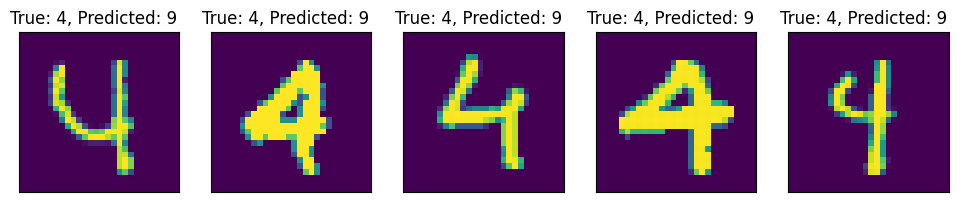

In [ ]:

def Q5():

  ### STUDENT START ###

  # train a 1-Nearest Neighbor model with mini_train_data
  model = KNeighborsClassifier(n_neighbors=1)
  model.fit(mini_train_data, mini_train_labels)

  # make predictions on the dev data set
  predictions = model.predict(dev_data)

  # generate the confusion matrix
  labels_sorted = [str(i) for i in range(10)]
  cm = confusion_matrix(dev_labels, predictions, labels=labels_sorted)

  # let's find the most common confusion, programmatically!
  # first, create a copy of the matrix and set the diagonal (correct predictions) to 0
  cm_errors = cm.copy()
  np.fill_diagonal(cm_errors, 0)

  # find the largest error value and its position (row, column)
  max_error_count = np.max(cm_errors) # number of times the error occured
  # get the true digit and the predicted digit
  true_digit_idx, pred_digit_idx = np.unravel_index(np.argmax(cm_errors), cm.shape)

  # and convert the indices to string labels for printing.
  true_digit = str(true_digit_idx)
  predicted_digit = str(pred_digit_idx)

  # print the formatted matrix with labels and highlighting.
  print("\nConfusion Matrix:\n")
  print("           \t\t(Predicted)")
  print("            " + "   ".join(labels_sorted))
  print("      " + "-" * 39)

  # loop through the confusion matrix and print the rows
  for i, row in enumerate(cm):

    # format each row with its true label.
    row_str = f"(True) {i}| " + " ".join([f"{val:3d}" for val in row])

    # highlight the row with the biggest error
    if i == true_digit_idx:
      row_str += f"  <-- The highest error is on this row ({max_error_count} times)"
    print(row_str)

  # print the dynamically found the digit that our model confuses the most
  print(f"\nThe model most often confuses the digit '{true_digit}' with '{predicted_digit}'.")

  # find and show examples of this specific misclassification.
  misclassified_indices = np.where((dev_labels == true_digit) & (predictions == predicted_digit))[0]

  print(f"\n\nExamples of the digit'{true_digit}' misclassified as digit '{predicted_digit}'")

  # plot imagage saved in misclassified_indices
  plt.figure(figsize=(12, 6))
  plt.rc('image', cmap='viridis') # set up the color map
  for i, index in enumerate(misclassified_indices[:5]):
    plt.subplot(1, 5, i + 1)
    image_data = dev_data.iloc[index].values.reshape(28, 28)
    plt.imshow(image_data)
    plt.title(f"True: {true_digit}, Predicted: {predicted_digit}  ")
    plt.xticks([])
    plt.yticks([])

  plt.show()

  ### STUDENT END ###


Q5()


Answer to part 3:

The model most often confuses the digit '4' with '9' (11 times).
